<a href="https://colab.research.google.com/github/CMPE-255-G5/times-series-anomaly-detection-on-twitter-data/blob/main/notebooks/Twitter_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Load data

In [1]:
# packages
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
import warnings
# Suppress future warning for use_inf_as_na
warnings.simplefilter(action='ignore'#,
                      # category=FutureWarning
                      )

In [3]:
# Download latest version
path = kagglehub.dataset_download("julienjta/twitter-mentions-volumes")

print("Path to dataset files:", path)

100%|██████████| 206k/206k [00:00<00:00, 51.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/julienjta/twitter-mentions-volumes/versions/1


In [4]:
# List files in the downloaded directory
print(os.listdir(path))

['dataset.csv']


In [5]:
# Construct the full path to the dataset.csv file
file_path = os.path.join(path, 'dataset.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,timestamp,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
0,2015-02-26 21:42:53,104,57.0,11,0.0,53.0,35.0,7.0,8.0,3.0,2.0
1,2015-02-26 21:47:53,100,43.0,10,0.0,64.0,41.0,4.0,8.0,2.0,2.0
2,2015-02-26 21:52:53,99,55.0,3,0.0,49.0,32.0,14.0,5.0,2.0,4.0
3,2015-02-26 21:57:53,154,64.0,4,0.0,48.0,36.0,6.0,13.0,36.0,3.0
4,2015-02-26 22:02:53,120,93.0,9,0.0,22.0,32.0,1.0,22.0,8.0,5.0


In [6]:
df.shape

(15902, 11)

In [7]:
# Convert timestamp to date time format
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [8]:
# Check min date, max date
min(df['timestamp']), max(df['timestamp'])

(Timestamp('2015-02-26 21:42:53'), Timestamp('2015-04-23 02:47:53'))

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15902 entries, 0 to 15901
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   15902 non-null  datetime64[ns]
 1   Apple       15902 non-null  int64         
 2   Amazon      15831 non-null  float64       
 3   Salesforce  15902 non-null  int64         
 4   CVS         15853 non-null  float64       
 5   Facebook    15833 non-null  float64       
 6   Google      15842 non-null  float64       
 7   IBM         15893 non-null  float64       
 8   Coca-Cola   15851 non-null  float64       
 9   Pfizer      15858 non-null  float64       
 10  UPS         15866 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(2)
memory usage: 1.3 MB


# 2. Data Preprocessing

## 2.1. Duplicates

In [10]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

## 2.2 Train - Val - Test Split

In [11]:
# Sort chronologically
df = df.sort_values('timestamp').reset_index(drop=True)

In [12]:
# Split train:validation:test with the ratio 70:15:15
n = len(df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

print(n, train_end, val_end)

15902 11131 13516


In [13]:
# Split the data
train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

In [14]:
# Check shapes of train, validation and test
train.shape, val.shape, test.shape

((11131, 11), (2385, 11), (2386, 11))

In [15]:
# Check min, max for train, val, test
for name, data in [('train', train), ('val', val), ('test', test)]:
    print(f'{name}: {min(df['timestamp'])} → {max(df['timestamp'])}')

train: 2015-02-26 21:42:53 → 2015-04-23 02:47:53
val: 2015-02-26 21:42:53 → 2015-04-23 02:47:53
test: 2015-02-26 21:42:53 → 2015-04-23 02:47:53


## 2.3. Missing Values

In [16]:
# Function to check missing values
def summarize_missing(train, val, test):
    missing_summary = pd.DataFrame(
        {
            "train": train.isnull().sum(),
            "val": val.isnull().sum(),
            "test": test.isnull().sum(),
        }
    )
    return missing_summary

# Check missing values
summarize_missing(train, val, test)

,train,val,test
timestamp,0,0,0
Apple,0,0,0
Amazon,0,0,71
Salesforce,0,0,0
CVS,0,0,49
Facebook,0,0,69
Google,0,0,60
IBM,0,0,9
Coca-Cola,0,0,51
Pfizer,0,0,44


In [17]:
# Check missing values in test set
test[test['Amazon'].isnull()]

,timestamp,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
15831,2015-04-22 20:57:53,120,NaN,9,1.0,78.0,50.0,3.0,16.0,1.0,1.0
15832,2015-04-22 21:02:53,109,NaN,7,0.0,117.0,61.0,4.0,21.0,2.0,1.0
15833,2015-04-22 21:07:53,44,NaN,6,0.0,NaN,56.0,2.0,15.0,0.0,0.0
15834,2015-04-22 21:12:53,74,NaN,4,0.0,NaN,59.0,1.0,13.0,0.0,2.0
15835,2015-04-22 21:17:53,60,NaN,5,0.0,NaN,57.0,6.0,13.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
15897,2015-04-23 02:27:53,44,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15898,2015-04-23 02:32:53,45,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15899,2015-04-23 02:37:53,48,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15900,2015-04-23 02:42:53,26,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values were found in the test set, concentrated in the last two days of the dataset and affecting only specific brand columns (Amazon, CVS, Facebook,
Google, IBM, Coca-Cola, Pfizer, UPS). This suggests brand-specific data collection issues rather than a full pipeline failure. Values were imputed using forward
fill (ffill) based on train set statistics to avoid data leakage.

In [18]:
# Copy train and val for consistent naming
train_imp = train.copy()
val_imp = val.copy()

# Calculate median of train data. Use median instead of mean to ignore the spikes
train_median = train.median()

# Impute the missing value
# ffill: forward fill carries the last known value forward
# if the very first row is missing then use train_median
test_imp = test.fillna(method='ffill').fillna(train_median)

In [19]:
test_imp.tail(71)

,timestamp,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
15831,2015-04-22 20:57:53,120,50.0,9,1.0,78.0,50.0,3.0,16.0,1.0,1.0
15832,2015-04-22 21:02:53,109,50.0,7,0.0,117.0,61.0,4.0,21.0,2.0,1.0
15833,2015-04-22 21:07:53,44,50.0,6,0.0,117.0,56.0,2.0,15.0,0.0,0.0
15834,2015-04-22 21:12:53,74,50.0,4,0.0,117.0,59.0,1.0,13.0,0.0,2.0
15835,2015-04-22 21:17:53,60,50.0,5,0.0,117.0,57.0,6.0,13.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
15897,2015-04-23 02:27:53,44,50.0,1,0.0,117.0,72.0,1.0,20.0,0.0,3.0
15898,2015-04-23 02:32:53,45,50.0,4,0.0,117.0,72.0,1.0,20.0,0.0,3.0
15899,2015-04-23 02:37:53,48,50.0,3,0.0,117.0,72.0,1.0,20.0,0.0,3.0
15900,2015-04-23 02:42:53,26,50.0,8,0.0,117.0,72.0,1.0,20.0,0.0,3.0


In [20]:
# Check missing values again
summarize_missing(train_imp, val_imp, test_imp)

,train,val,test
timestamp,0,0,0
Apple,0,0,0
Amazon,0,0,0
Salesforce,0,0,0
CVS,0,0,0
Facebook,0,0,0
Google,0,0,0
IBM,0,0,0
Coca-Cola,0,0,0
Pfizer,0,0,0


# 3. EDA

In [125]:
company_colors = {
    "Amazon":     "#ff6315",
    "Apple":      "#666666",
    "Google":     "#34a853",
    "Facebook":   "#006fea",
    "Coca-Cola":  "#e71727",
    "Salesforce": "#0d9dda",
    "IBM":        "#0f62fe",
    "UPS":        "#704221",
    "CVS":        "#cc0000",
    "Pfizer":     "#2700bf",
}

In [ ]:
# Find median number of tweets per five minutes (sorted by median and variance, because Pfizer and CVS have the same median but different variance)
stats = df.drop(columns='timestamp').agg(['median', 'var']).T
company_medians = stats.sort_values(['median', 'var'], ascending=False)['median'].rename('Median Tweets')
company_medians

,Median Tweets
Amazon,50.0
Apple,47.0
Google,16.0
Facebook,14.0
Coca-Cola,8.0
IBM,3.0
UPS,2.0
Salesforce,2.0
Pfizer,0.0
CVS,0.0


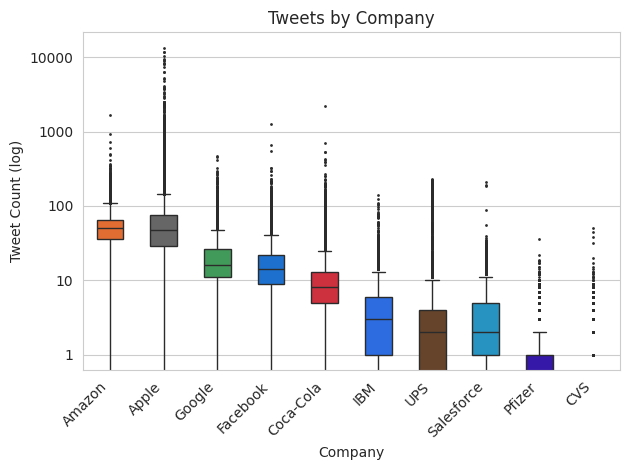

In [ ]:
# Create boxplots to look at distribution and spot outliers. Sorted by median number of tweets per five minutes
palette = [company_colors[company] for company in company_medians.index]
sns.set_style('whitegrid')
sns.boxplot(data=df.drop(columns='timestamp')[company_medians.index], width=.5, flierprops={'marker': '.', 'markersize': 2}, palette=palette)
plt.title('Tweets by Company')
plt.xlabel('Company')
plt.ylabel('Tweet Count (log)')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter('{x:g}')
plt.tight_layout()
plt.show()

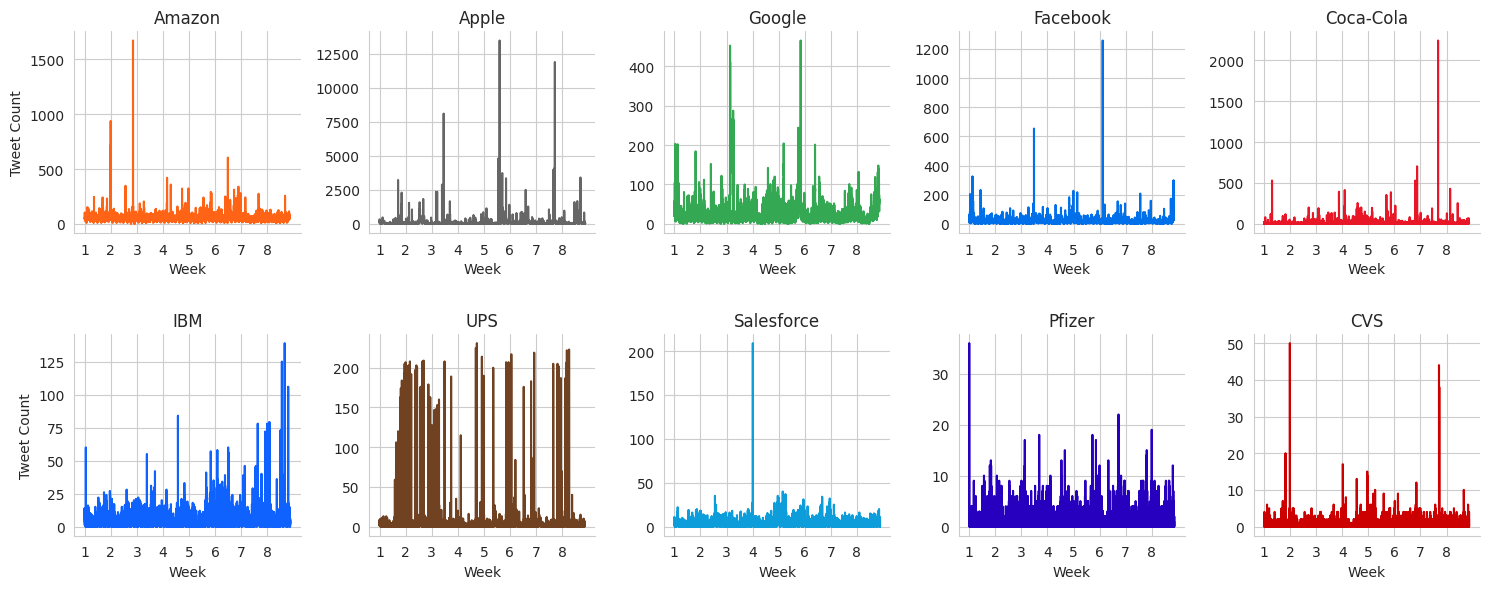

In [ ]:
# Create a long format version of the original df
df_long_format = df.melt(id_vars='timestamp', var_name='company', value_name='tweet_count')
df_long_format['week'] = (df_long_format['timestamp'] - df_long_format['timestamp'].min()).dt.days // 7 + 1

# Create line graphs for each company, that show tweet number of time
week_ticks = df_long_format.groupby('week')['timestamp'].min()
grid = sns.FacetGrid(df_long_format, col='company', col_wrap=5, sharey=False, col_order=company_medians.index)
grid.map(sns.lineplot, 'timestamp', 'tweet_count')
grid.set_axis_labels('Week', 'Tweet Count')
for axes in grid.axes.flatten():
    axes.set_xticks(week_ticks.values)
    axes.set_xticklabels(week_ticks.index)
    axes.tick_params(axis='x', labelbottom=True)
    axes.set_xlabel('Week')
    axes.xaxis.label.set_visible(True)
    company = axes.get_title().replace('company = ', '')
    axes.set_title(company)
    for line in axes.get_lines():
        line.set_color(company_colors[company])
plt.tight_layout()
grid.figure.subplots_adjust(hspace=0.5)
plt.show()

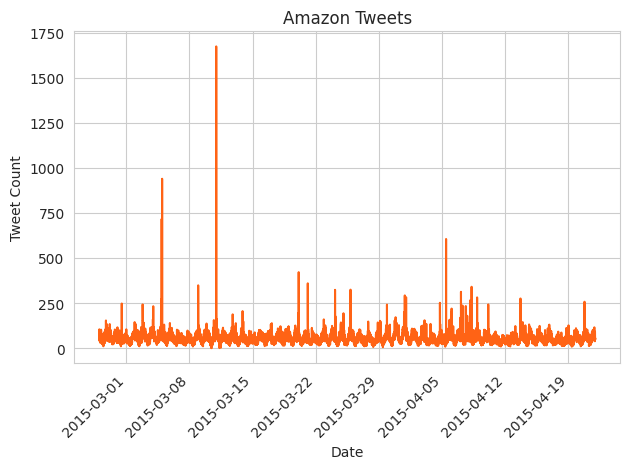

In [ ]:
# Look at spikes in Amazon Tweets specifically (Amazon has highest volume of tweets)
sns.lineplot(x=df['timestamp'], y=df['Amazon'], color=company_colors['Amazon'])
plt.title('Amazon Tweets')
plt.xlabel('Date')
plt.ylabel('Tweet Count')
plt.xticks(pd.date_range(df['timestamp'].min(), df['timestamp'].max(), freq='W'), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. Feature Engineering

## 4.1 Introduce new features

**Features to create:**

| Category | Features | Why |
|---|---|---|
| Time-based | `day_of_week`, `is_weekend`, `month` | Mentions naturally differ weekday vs weekend and across seasons |
| Moving average | `rolling_mean_7d`, `rolling_std_7d` | Defines local "normal" baseline |
| Deviation | `deviation_from_MA`, `deviation_%` | Direct anomaly signal |
| Lag | `lag_1d`, `lag_7d` | Captures momentum and weekly pattern |
| Rate of change | `pct_change_1d` | Catches sudden jumps |
| Decomposition | `trend`, `seasonal`, `residual` | Residual is purest anomaly signal |
| Cross-brand | `total_mentions`, `brand_share`, `brands_spiking` | Detects coordinated vs isolated spikes |

**1. Moving Average:**

E.g. Raw Apple mentions:
| Day | Apple Mentions |
|---|---|
| Mon | 500 |
| Tues | 520 |
| Wed | 8,000 |
| Thurs | 480 |
| Fri | 510 |

*   7-day moving average = 550
*   It says a normal day of Apple is around 550 mentions. True normal baseline is clear despite of the spike on Wed.
*   Consider 3-day MA if some models struggle.


**2. Deviation from MA:**

E.g. deviation = raw - moving_average = 8,000 - 500 = 7,450
*   It says if 8,000 is unusually high compared to recent normal
*   Great tool to detect clear anomaly


**3. Lag:**

**lag_1d**: to compare with the yesterday's mention. E.g.
| Day | Apple Mentions | `lag_1d` (yesterday) | Note |
|---|---|---|---|
| Monday | 500 | 510 | Sunday's value — normal |
| Tuesday | 520 | 500 | normal |
| Wednesday | 8,000 | 520 | 8,000 vs 520 — suspicious |
| Thursday | 480 | 8,000 | dropped back down |

**lag_7d**: to compare with the same day last week's mention. E.g.
| Day | Apple Mentions | `lag_7d` (same day last week) | Note |
|---|---|---|---|
| This Monday | 500 | 490 | Mondays are typically ~500 — normal |
| This Wednesday | 8,000 | 510 | 8,000 vs 510 — suspicious |


**4. Rate of change:**

Calculate day by day percentage change. E.g.
| Day | Apple Mentions | `pct_change_1d` | Note |
|---|---|---|---|
| Monday | 500 | — | no previous day |
| Tuesday | 520 | +4% | slight increase — normal |
| Wednesday | 8,000 | +1,438% | massive jump — suspicious |
| Thursday | 480 | -94% | crashed back down — suspicious |
| Friday | 510 | +6% | back to normal |


**5. Decomposition:**
Decomposition separates the raw mention signal into three components:


*   **Trend**: long-term growth or decline of brand mentions
*   **Seasonal**: Repeating weekly pattern (e.g. weekday vs weekend)
*   **Residual**: What remains after removing trend and seasonality. The residual is the purest anomaly signal. High unexplained spikes are anomalies.  


**6. Cross-brand features:**
*   **total_mentions:** to comapre a brand's mention to overall market activity. E.g.
| Scenario | `total_mentions` | Apple Mentions | Note |
|---|---|---|---|
| Normal day | 5,000 | 500 | Apple's share is normal |
| Market event day | 50,000 | 500 | Apple unusually quiet during market spike |
| Apple viral day | 5,500 | 8,000 | Apple spike, market barely moved |

*   **brand_share:** share of a brand's mention of total mentions
| Scenario | Apple Mentions | `total_mentions` | `brand_share` | Note |
|---|---|---|---|---|
| Normal day | 500 | 5,000 | 500 / 5,000 = 10% | normal |
| Isolated spike | 8,000 | 9,000 | 8,000 / 9,000 = 89% | dominating the conversation |
| Market event | 8,000 | 80,000 | 8,000 / 80,000 = 10% | normal share, just bigger pie |

*   **brand_spiking:** how many brands spiked together, defined as brands whose daily mentions exceed 2x of their historical mean.

| Scenario | `brands_spiking` | Note |
|---|---|---|
| Normal day | 0 | quiet day, no unusual activity |
| Isolated spike | 1 | only Apple spiked — brand-specific event |
| Market event | 9 | all brands spiked — external event |

## 4.2. Create functions and features

### Create fe functions

In [25]:
# function to add time based
def add_time_features(df, timestamp_col):
    """Day of week and weekend flag from timestamp."""
    df['day_of_week'] = df[timestamp_col].dt.dayofweek
    df['is_weekend']  = (df[timestamp_col].dt.dayofweek >= 5).astype(int)
    df['month'] = df[timestamp_col].dt.month
    return df

# function to add moving average
def add_rolling_features(df, brand_cols, window=7):
    """Rolling mean, std and deviation from moving average per brand."""
    for brand in brand_cols:
        roll = df[brand].rolling(window=window, min_periods=1)

        df[f'{brand}_rolling_mean_{window}d'] = roll.mean()
        df[f'{brand}_rolling_std_{window}d']  = roll.std()

        # Deviation from moving average — core anomaly signal
        df[f'{brand}_deviation']   = df[brand] - df[f'{brand}_rolling_mean_{window}d']
        df[f'{brand}_deviation_%'] = (
            df[f'{brand}_deviation'] / df[f'{brand}_rolling_mean_{window}d']
        ).replace([np.inf, -np.inf], 0) * 100

    return df

# function to add lag features
def add_lag_features(df, brand_cols):
    """Yesterday and same day last week per brand."""
    for brand in brand_cols:
        df[f'{brand}_lag_1d'] = df[brand].shift(1)
        df[f'{brand}_lag_7d'] = df[brand].shift(7)
    return df

# function to add rate of change
def add_rate_of_change(df, brand_cols):
    """Day over day % change per brand."""
    for brand in brand_cols:
        df[f'{brand}_pct_change_1d'] = df[brand].pct_change(1).replace(
            [np.inf, -np.inf], 0
        )
    return df

# function to add decomposition
def add_decomposition(df, brand_cols, period=7):
    """
    Trend, seasonal and residual components per brand.
    Residual is the purest anomaly signal.
    """
    for brand in brand_cols:
        result = seasonal_decompose(
            df[brand],
            model='additive',
            period=period,
            extrapolate_trend='freq'   # avoids NaN at edges
        )
        df[f'{brand}_trend']    = result.trend
        df[f'{brand}_seasonal'] = result.seasonal
        df[f'{brand}_residual'] = result.resid
    return df

# functioon to add cross brand features
def add_cross_brand_features(df, brand_cols):
    """
    Market-wide signals — detects coordinated vs isolated spikes.
    """
    df['total_mentions'] = df[brand_cols].sum(axis=1)
    df['mean_mentions']  = df[brand_cols].mean(axis=1)

    # Each brand's share of total daily mentions
    for brand in brand_cols:
        df[f'{brand}_share'] = (
            df[brand] / df['total_mentions']
        ).replace([np.inf, -np.inf], 0)

    # Number of brands spiking on same day (> 2x their historical mean)
    brand_means          = df[brand_cols].mean()
    df['brands_spiking'] = (df[brand_cols] > brand_means * 2).sum(axis=1)

    return df


def engineer_features(df, brand_cols, timestamp_col='timestamp', window=7, period=7):
    """
    Master function — runs all feature engineering steps in correct order.

    Parameters:
        df            : raw dataframe (before splitting)
        brand_cols    : list of brand column names
        timestamp_col : name of the timestamp column
        window        : rolling window in days (default 7)
        period        : seasonal decomposition period in days (default 7)

    Returns:
        df with all features added, NaN rows dropped
    """
    df = df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    df = df.sort_values(timestamp_col).reset_index(drop=True)

    df = add_time_features(df, timestamp_col)
    df = add_rolling_features(df, brand_cols, window)
    df = add_lag_features(df, brand_cols)
    df = add_rate_of_change(df, brand_cols)
    df = add_decomposition(df, brand_cols, period)
    df = add_cross_brand_features(df, brand_cols)

    # Drop NaN rows from lag/rolling warmup
    # df = df.dropna().reset_index(drop=True)  # reconsider this!

    print(f"Features created: {df.shape[1]} columns, {df.shape[0]} rows")
    return df

### Create new features

In [26]:
# select brand columns
brand_cols = [c for c in df.columns if c != 'timestamp']

# create features
train_fe = engineer_features(train_imp, brand_cols)
val_fe = engineer_features(val_imp, brand_cols)
test_fe = engineer_features(test_imp, brand_cols)

Features created: 127 columns, 11131 rows
Features created: 127 columns, 2385 rows
Features created: 127 columns, 2386 rows


In [27]:
# Check new features
print(f"Original features:    {len(brand_cols)}")
print(f"Engineered features:  {train_fe.shape[1]}")
print(train_fe.head())

Original features:    10
Engineered features:  127
            timestamp  Apple  Amazon  Salesforce  CVS  Facebook  Google   IBM  \
0 2015-02-26 21:42:53    104    57.0          11  0.0      53.0    35.0   7.0   
1 2015-02-26 21:47:53    100    43.0          10  0.0      64.0    41.0   4.0   
2 2015-02-26 21:52:53     99    55.0           3  0.0      49.0    32.0  14.0   
3 2015-02-26 21:57:53    154    64.0           4  0.0      48.0    36.0   6.0   
4 2015-02-26 22:02:53    120    93.0           9  0.0      22.0    32.0   1.0   

   Coca-Cola  Pfizer  ...  Amazon_share  Salesforce_share  CVS_share  \
0        8.0     3.0  ...      0.203571          0.039286        0.0   
1        8.0     2.0  ...      0.156934          0.036496        0.0   
2        5.0     2.0  ...      0.209125          0.011407        0.0   
3       13.0    36.0  ...      0.175824          0.010989        0.0   
4       22.0     8.0  ...      0.298077          0.028846        0.0   

   Facebook_share  Google_sha

# 5. Feature Scaling

Scaling for distance-based models (e.g. one-class SVM) or deep learning models (autoencoders).

In [28]:
# Check basic desciptive statistics
train_fe.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,11131,2015-03-18 05:27:52.999999744,2015-02-26 21:42:53,2015-03-08 13:35:23,2015-03-18 05:27:53,2015-03-27 21:20:23,2015-04-06 13:12:53,NaN
Apple,11131.0,80.82679,0.0,28.0,44.0,73.0,13479.0,282.459239
Amazon,11131.0,54.206989,0.0,37.0,51.0,66.0,1673.0,32.331066
Salesforce,11131.0,3.465637,0.0,1.0,2.0,5.0,209.0,5.064131
CVS,11131.0,0.343455,0.0,0.0,0.0,0.0,50.0,1.026337
...,...,...,...,...,...,...,...,...
IBM_share,11104.0,0.023111,0.0,0.008475,0.017699,0.031008,0.402685,0.023398
Coca-Cola_share,11104.0,0.062602,0.0,0.028571,0.048193,0.075784,0.850962,0.060258
Pfizer_share,11104.0,0.00466,0.0,0.0,0.0,0.007299,0.13,0.007955
UPS_share,11104.0,0.0251,0.0,0.0,0.009434,0.019608,0.808696,0.074125


In [29]:
# Standard Normalization Scaling
scaler = StandardScaler()

# select brand columns
scaled_cols = [c for c in train_fe.columns if c != 'timestamp']

# Function to scale
def scale_features(df, scaler, cols, timestamp_col='timestamp', fit=False):
    """
    Sets timestamp as index, scales specified columns,
    and returns a DataFrame with timestamp as index.

    Parameters:
        df            : input dataframe
        scaler        : sklearn scaler instance
        cols          : columns to scale
        timestamp_col : name of timestamp column (default 'timestamp')
        fit           : if True, fit scaler on this df first (use for train only)

    Returns:
        scaled DataFrame with timestamp as index
    """
    # Set timestamp as index if it's still a column
    if timestamp_col in df.columns:
        df = df.set_index(timestamp_col)

    array = scaler.fit_transform(df[cols]) if fit else scaler.transform(df[cols])
    return pd.DataFrame(array, columns=cols, index=df.index)


# Scale
train_scaled = scale_features(train_fe, scaler, scaled_cols, fit=True)
val_scaled = scale_features(val_fe, scaler, scaled_cols)
test_scaled = scale_features(test_fe, scaler, scaled_cols)

In [30]:
# Sanity check
train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Apple,11131.0,5.106767e-18,1.000045,-0.286167,-0.187033,-0.130385,-0.027711,47.436137
Amazon,11131.0,5.872782e-17,1.000045,-1.676698,-0.532236,-0.099197,0.364774,50.071523
Salesforce,11131.0,3.064060e-17,1.000045,-0.684380,-0.486904,-0.289428,0.303000,40.588124
CVS,11131.0,-2.553383e-18,1.000045,-0.334657,-0.334657,-0.334657,-0.334657,48.384496
Facebook,11131.0,5.872782e-17,1.000045,-0.844511,-0.419348,-0.183147,0.194775,58.583769
...,...,...,...,...,...,...,...,...
IBM_share,11104.0,-2.047674e-17,1.000045,-0.987805,-0.625594,-0.231330,0.337493,16.223275
Coca-Cola_share,11104.0,0.000000e+00,1.000045,-1.038949,-0.564776,-0.239139,0.218761,13.083652
Pfizer_share,11104.0,-2.047674e-17,1.000045,-0.585741,-0.585741,-0.585741,0.331833,15.756251
UPS_share,11104.0,1.663735e-17,1.000045,-0.338638,-0.338638,-0.211361,-0.074101,10.571786


In [31]:
print(train_scaled.head())

                        Apple    Amazon  Salesforce       CVS  Facebook  \
timestamp                                                                 
2015-02-26 21:42:53  0.082045  0.086392    1.487857 -0.334657  1.659224   
2015-02-26 21:47:53  0.067883 -0.346648    1.290381 -0.334657  2.178867   
2015-02-26 21:52:53  0.064342  0.024529   -0.091952 -0.334657  1.470263   
2015-02-26 21:57:53  0.259069  0.302911    0.105524 -0.334657  1.423023   
2015-02-26 22:02:53  0.138692  1.199922    1.092905 -0.334657  0.194775   

                       Google       IBM  Coca-Cola     Pfizer       UPS  ...  \
timestamp                                                                ...   
2015-02-26 21:42:53  0.709450  0.656602  -0.180474   1.482502 -0.172738  ...   
2015-02-26 21:47:53  1.010792 -0.022198  -0.180474   0.794156 -0.172738  ...   
2015-02-26 21:52:53  0.558778  2.240468  -0.356757   0.794156 -0.086547  ...   
2015-02-26 21:57:53  0.759673  0.430335   0.113330  24.197939 -0.129643  .